# Data exploration of collision_dataset.txt
An exploration of the dataset generated by Benjamin Vollebregt using CTC simulations for two colliding $H_2$ molecules.

## Info

### Dataset explanation

collision_dataset.txt contains 10.000 the translational and rotational energies of two colliding particles for 10.000 simulations.

There are 7 columns containing the following:

'b' = impact parameter

'Etr' = precollisional translational kinetic energy of particle 1 + translational kinetic energy of particle 2 [in Kelvin]. Both particles start with equal velocity so $Etr_A = Etr_B = 0.5 Etr$.

'Er1' = precollisional rotational kinetic energy of particle 1

'Er2' = precollisional rotational kinetic energy of particle 2

'Etrp'= postcollisional translational kinetic energy of particle 1 + translational kinetic energy of particle 2 [in Kelvin]

'Er1p' = postcollisional rotational kinetic energy of particle 1

'Er2p' = postcollisional rotational kinetic energy of particle 2

# Velocity inspection

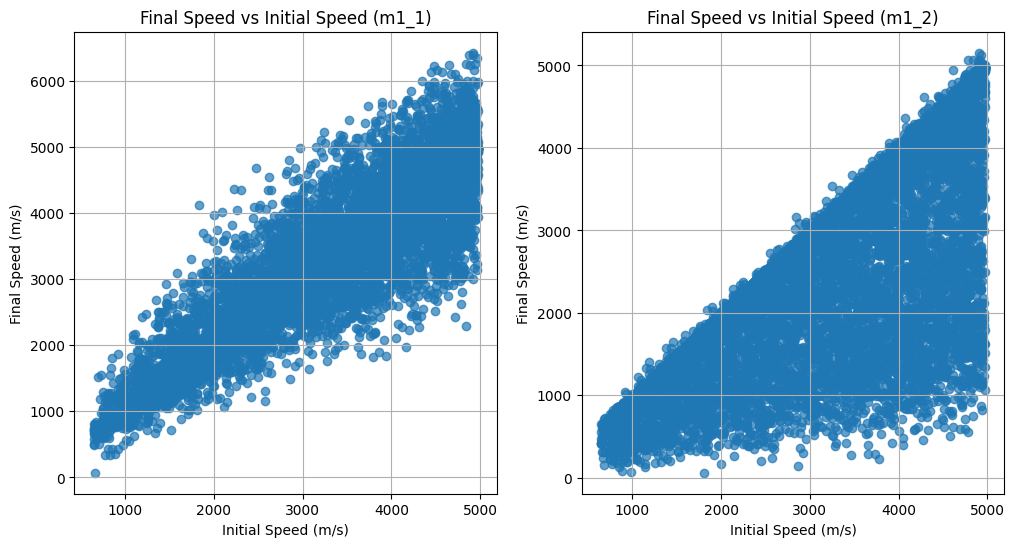

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

m1_1_DATA_FILE = "CTC_simulation_results_m1_1.csv"
m1_2_DATA_FILE = "CTC_simulation_results_m1_2.csv"

df_m1_1 = pd.read_csv(m1_1_DATA_FILE)
df_m1_2 = pd.read_csv(m1_2_DATA_FILE)

# Plot initial vs final speed
fig, ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].scatter(df_m1_1["V_init"], df_m1_1["V_final"], alpha=0.7)
ax[0].set_ylim(0,7000)
ax[0].set_xlabel("Initial Speed (m/s)")
ax[0].set_ylabel("Final Speed (m/s)")
ax[0].set_title("Final Speed vs Initial Speed (m1_1)")
ax[0].grid()
ax[1].scatter(df_m1_2["V_init"], df_m1_2["V_final"], alpha=0.7)
ax[1].set_xlabel("Initial Speed (m/s)")
ax[1].set_ylabel("Final Speed (m/s)")
ax[1].set_title("Final Speed vs Initial Speed (m1_2)")
ax[1].grid()
plt.show()

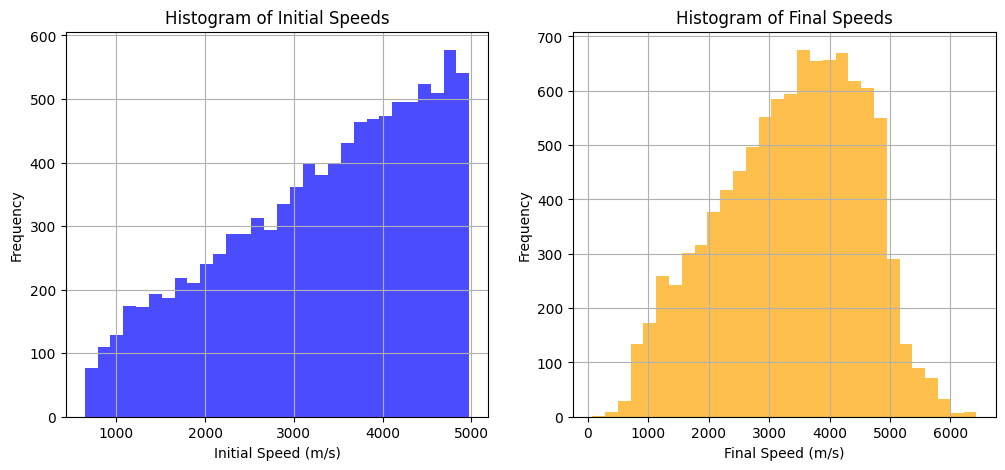

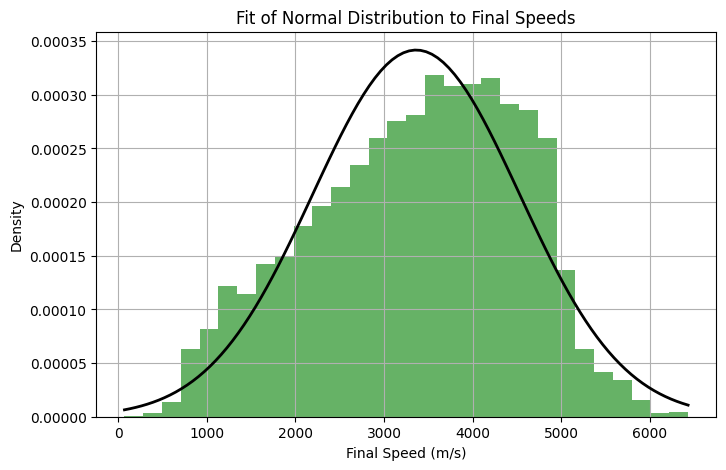

In [28]:
# Histograms of initial and final speeds
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(df["V_init"], bins=30, alpha=0.7, color='blue')
ax[0].set_xlabel("Initial Speed (m/s)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Histogram of Initial Speeds")
ax[0].grid()
ax[1].hist(df["V_final"], bins=30, alpha=0.7, color='orange')
ax[1].set_xlabel("Final Speed (m/s)")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Histogram of Final Speeds")
ax[1].grid()
plt.show()

# Fit pdf to final speed data
from scipy import stats
final_speeds = df["V_final"].dropna()
mu, std = stats.norm.fit(final_speeds)
xmin, xmax = final_speeds.min(), final_speeds.max()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(final_speeds, bins=30, density=True, alpha=0.6, color='g')
ax.plot(x, p, 'k', linewidth=2)
ax.set_xlabel("Final Speed (m/s)")
ax.set_ylabel("Density")
ax.set_title("Fit of Normal Distribution to Final Speeds")
ax.grid()
plt.show()

# Energy inspection

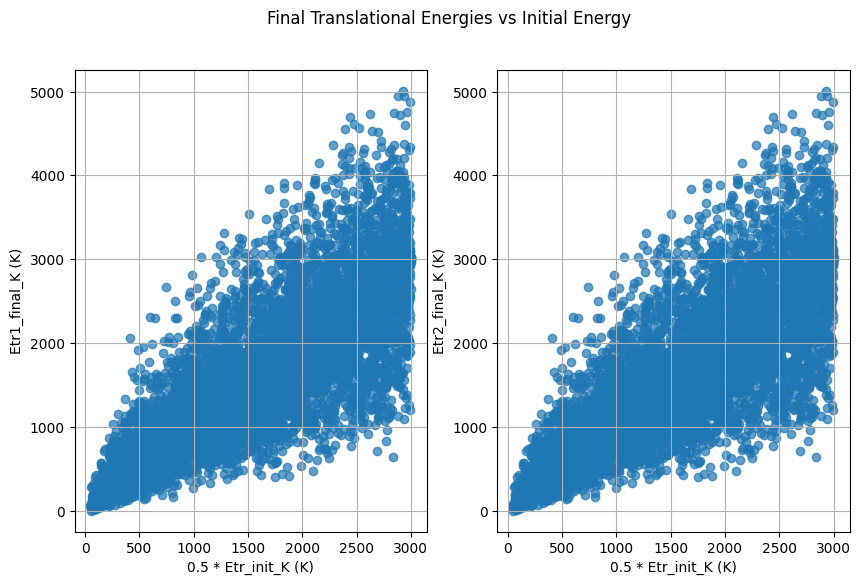

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].scatter(0.5 * df["Etr_init_K"], df["Etr1_final_K"], alpha=0.7)
ax[0].set_xlabel("0.5 * Etr_init_K (K)")
ax[0].set_ylabel("Etr1_final_K (K)")
ax[0].grid()
ax[1].scatter(0.5 * df["Etr_init_K"], df["Etr2_final_K"], alpha=0.7)
ax[1].set_xlabel("0.5 * Etr_init_K (K)")
ax[1].set_ylabel("Etr2_final_K (K)")
ax[1].grid()
plt.suptitle("Final Translational Energies vs Initial Energy")
plt.show()

## Data distribution
Plot histograms of pre- and post-collisional data to visualize the data distributions

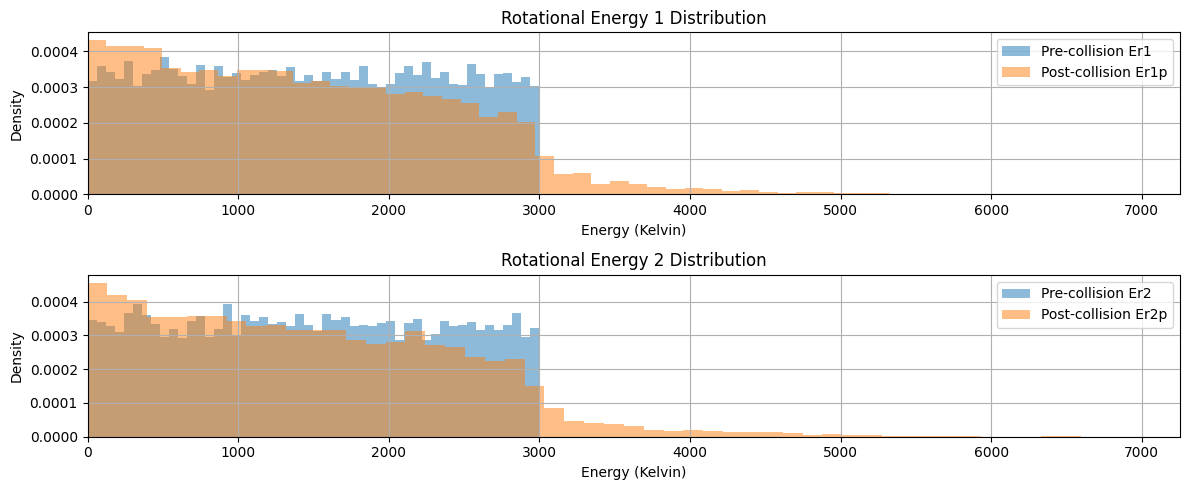

In [30]:
# Plot histogram of pre- and post-collision energies
# Rotational energies
fig, ax = plt.subplots(2,1)
fig.set_size_inches(12, 5)
xmax = max(df['Er1_init_K'].max(), df['Er1_final_K'].max(), df['Er2_init_K'].max(), df['Er2_final_K'].max())*1.1

ax[0].hist(df['Er1_init_K'], bins=50, alpha=0.5, label='Pre-collision Er1', density=True)
ax[0].hist(df['Er1_final_K'], bins=50, alpha=0.5, label='Post-collision Er1p', density=True)
ax[0].set_xlim(0, xmax)
ax[0].set_title('Rotational Energy 1 Distribution')
ax[0].set_xlabel('Energy (Kelvin)')
ax[0].set_ylabel('Density')
ax[0].legend()
ax[0].grid()

ax[1].hist(df['Er2_init_K'], bins=50, alpha=0.5, label='Pre-collision Er2', density=True)
ax[1].hist(df['Er2_final_K'], bins=50, alpha=0.5, label='Post-collision Er2p', density=True)
ax[1].set_xlim(0, xmax)
ax[1].set_title('Rotational Energy 2 Distribution')
ax[1].set_xlabel('Energy (Kelvin)')
ax[1].set_ylabel('Density')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

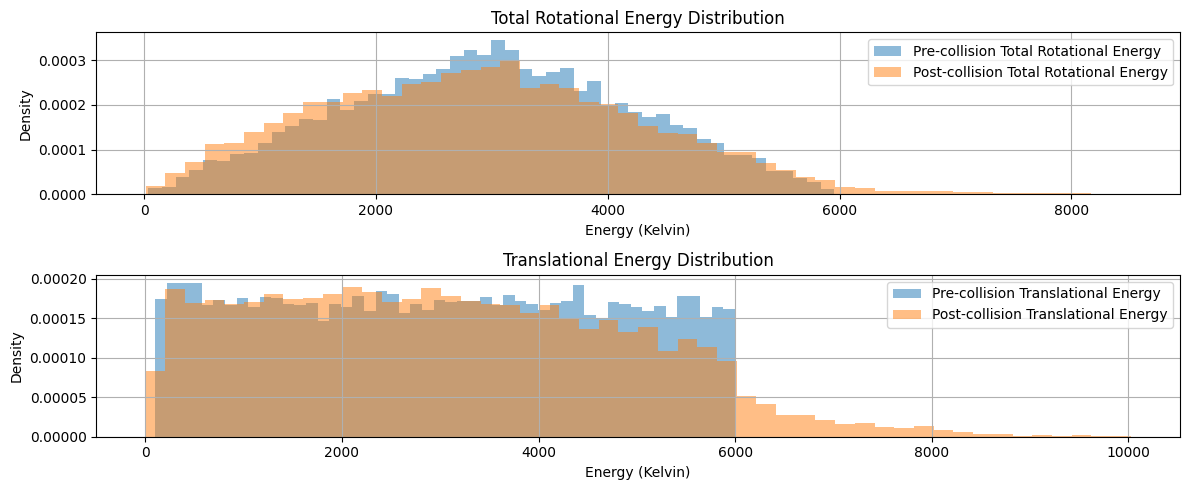

In [31]:
# Total rotational energy and translational energy
fig, ax = plt.subplots(2,1)
fig.set_size_inches(12, 5)
ax[0].hist(df['Er1_init_K'] + df['Er2_init_K'], bins=50, alpha=0.5, label='Pre-collision Total Rotational Energy', density=True)
ax[0].hist(df['Er1_final_K'] + df['Er2_final_K'], bins=50, alpha=0.5, label='Post-collision Total Rotational Energy', density=True)
ax[0].set_title('Total Rotational Energy Distribution')
ax[0].set_xlabel('Energy (Kelvin)')
ax[0].set_ylabel('Density')
ax[0].legend()
ax[0].grid()

ax[1].hist(df['Etr_init_K'], bins=50, alpha=0.5, label='Pre-collision Translational Energy', density=True)
ax[1].hist(df['Etr1_final_K'] + df['Etr2_final_K'], bins=50, alpha=0.5, label='Post-collision Translational Energy', density=True)
ax[1].set_title('Translational Energy Distribution')
ax[1].set_xlabel('Energy (Kelvin)')
ax[1].set_ylabel('Density')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

The above plot shows clearly that the precollisional data is initialized in the [0K,3000K] energy interval. Post collision the data is less centered around the mean and has a longer tail meaning that the distribution of energies tends to be more spread out after the collision because the randomness of the collision process pushes the distribution toward a normal distribution.

# KL divergence
Calculate the Kullback-Leibler divergence between the pre- and post-collisional speed distributions to quantify the difference between them.

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("CTC_simulation_results.csv")
v_init = df["V_init"]
v_final = df["V_final"]

# Create Histograms (Discretize the distributions)
# We must use the same bins for both to align them.
# We create bins covering the full range of both datasets.
num_bins = 50
min_val = min(v_init.min(), v_final.min())
max_val = max(v_init.max(), v_final.max())
bins = np.linspace(min_val, max_val, num_bins)

# Get the counts and normalize them to create probability distributions
# density=False gets counts, we normalize manually to ensure sum(P) = 1
v_final_counts, _ = np.histogram(v_final, bins=bins)
v_init_counts, _ = np.histogram(v_init, bins=bins)

# Handle zeros (Smoothing)
# KL divergence explodes if Q(i) is 0 where P(i) > 0. 
# We add a small epsilon to avoid log(0) or division by zero errors.
epsilon = 1e-10
v_final_counts = v_final_counts + epsilon
v_init_counts = v_init_counts + epsilon

# Normalize to get probabilities
v_final_norm = v_final_counts / np.sum(v_final_counts)  # Final distribution
v_init_norm = v_init_counts / np.sum(v_init_counts)  # Initial distribution

# Compute KL Divergence
# D_KL(P || Q)
kl_divergence = entropy(v_final_norm, v_init_norm)

print(f"KL Divergence D_KL(V_final || V_init): {kl_divergence:.4f}")

# Plot to visualize the overlap
plt.figure(figsize=(8, 5))
plt.title(f"Speed Distributions (KL Divergence: {kl_divergence:.2f})")
plt.bar(bins[:-1], v_final_norm, width=np.diff(bins), alpha=0.5, label='V_final', align='edge')
plt.bar(bins[:-1], v_init_norm, width=np.diff(bins), alpha=0.5, label='V_init', align='edge')
plt.legend()
plt.xlabel("Speed (m/s)")
plt.ylabel("Probability")

FileNotFoundError: [Errno 2] No such file or directory: 'CTC_simulation_results.csv'